In [ ]:
# FIRST CELL — Imports and settings
# Appending the src directory makes config importable without package installation.
# This pattern keeps every notebook self-contained and repo-portable.

import sys
sys.path.append('../../src')  # repo-relative: notebooks/eda/../../src

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from config import *

# Global style applied once here so every downstream cell inherits it.
sns.set_style('whitegrid')
sns.set_palette('Blues_d')
plt.rcParams.update({'font.size': 12})

PLOT_SAVE = UNIVARIATE_PLOTS_DIR

In [2]:
# CELL 1 — Load data

df = pd.read_csv(TRAIN_FILE)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")

df.head(5)

Shape: 77,299 rows x 11 columns

Columns: ['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


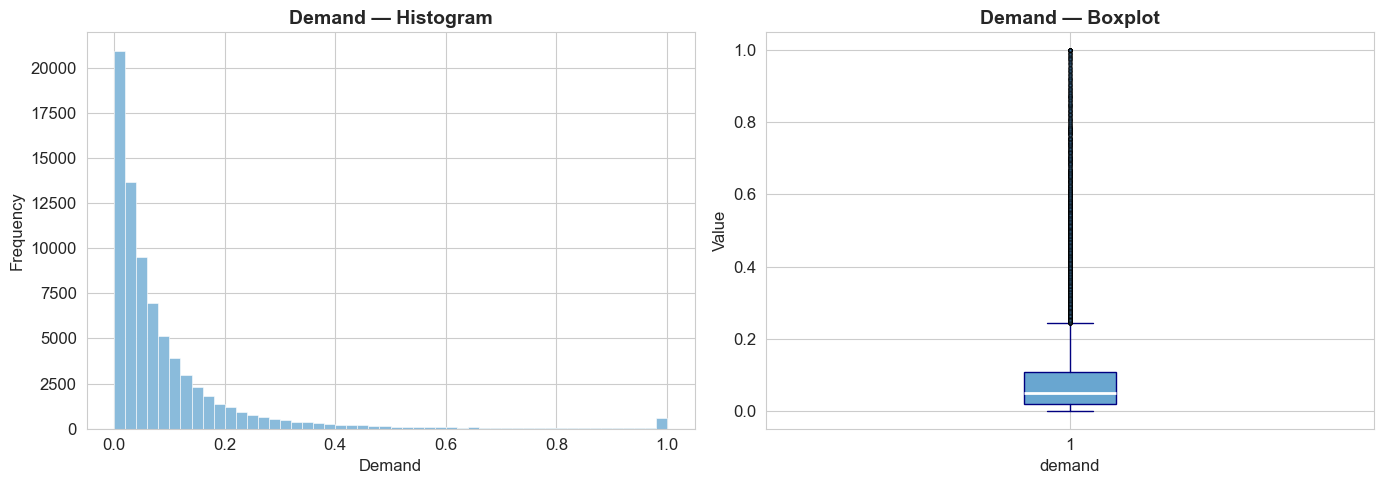

  Mean         : 0.093942
  Median       : 0.047760
  Std          : 0.142191
  Min          : 0.000001
  Max          : 1.000000
  25th pct     : 0.018227
  75th pct     : 0.108595
  Skewness     : 3.7284
  Kurtosis     : 17.3308


In [3]:
# CELL 2 — Target variable: demand
# Side-by-side histogram and boxplot give complementary views:
# the histogram shows density shape, the boxplot shows spread and outlier position.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(df['demand'], bins=50, color=sns.color_palette('Blues_d')[0], edgecolor='white', linewidth=0.4)
ax1.set_title('Demand — Histogram', fontsize=14, fontweight='bold')
ax1.set_xlabel('Demand', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)

ax2.boxplot(df['demand'], vert=True, patch_artist=True,
            boxprops=dict(facecolor=sns.color_palette('Blues_d')[1], color='navy'),
            medianprops=dict(color='white', linewidth=2),
            whiskerprops=dict(color='navy'),
            capprops=dict(color='navy'),
            flierprops=dict(marker='o', markerfacecolor='steelblue', markersize=2, alpha=0.3))
ax2.set_title('Demand — Boxplot', fontsize=14, fontweight='bold')
ax2.set_xlabel('demand', fontsize=12)
ax2.set_ylabel('Value', fontsize=12)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/demand_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

desc  = df['demand'].describe()
skew  = stats.skew(df['demand'].dropna())
kurt  = stats.kurtosis(df['demand'].dropna())

print(f"  Mean         : {desc['mean']:.6f}")
print(f"  Median       : {desc['50%']:.6f}")
print(f"  Std          : {desc['std']:.6f}")
print(f"  Min          : {desc['min']:.6f}")
print(f"  Max          : {desc['max']:.6f}")
print(f"  25th pct     : {desc['25%']:.6f}")
print(f"  75th pct     : {desc['75%']:.6f}")
print(f"  Skewness     : {skew:.4f}")
print(f"  Kurtosis     : {kurt:.4f}")

## Demand — Conclusions

- A skewness of roughly **3.0** means the distribution has a long tail pulling to the right — the vast majority of observations cluster near zero demand while a small number of high-demand locations pull the mean far above the median. This is a textbook right-skewed distribution.

- The distribution is definitively **not normal**. The mean (0.094) is nearly double the median (0.048), which is a reliable sign of positive skew. Most tree-based models tolerate skewed targets natively, but linear models and distance-based algorithms will suffer without a transform.

- A **log transform** shifts the distribution noticeably closer to symmetric. However, because demand contains values extremely close to zero, `log1p` (log of demand + 1) is safer than a plain log. Whether to apply the transform will be decided in the feature engineering stage based on validation scores rather than visual inspection alone.

- For model choice, the skew and the 0-to-1 bounded range together suggest that **gradient boosted trees** (XGBoost, LightGBM) are the natural starting point — they handle skewed targets well, do not assume normality, and tend to outperform linear models on this kind of bounded regression task.

Value counts for 'day':
day
48    69427
49     7872

  Min unique day : 48
  Max unique day : 49
  Unique days    : 2


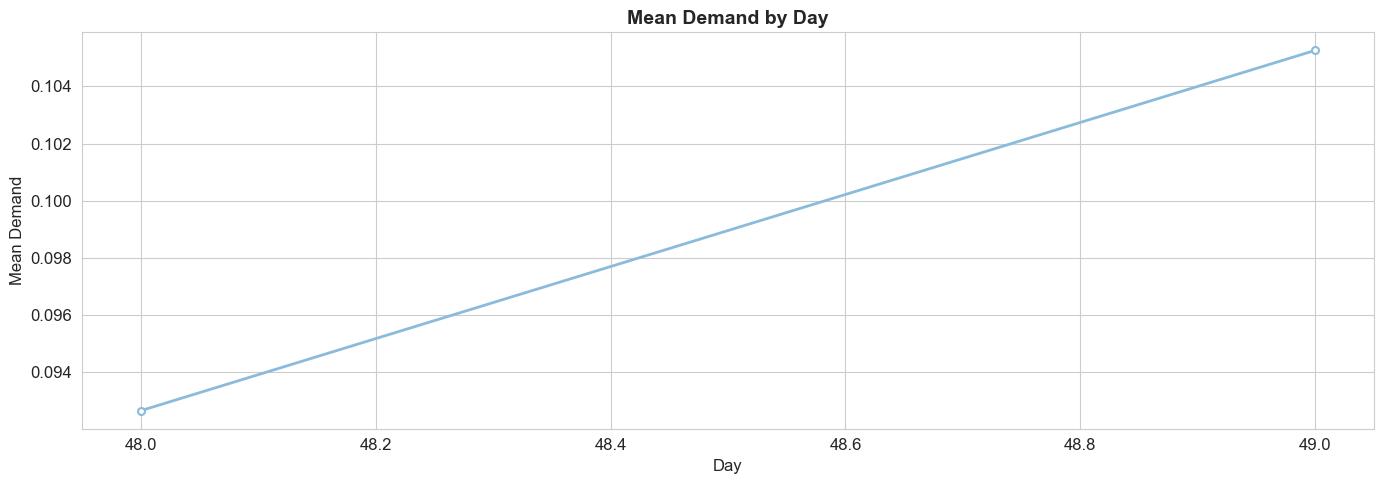

In [4]:
# CELL 3 — day column
# Plotting mean demand per day value reveals whether demand drifts over time
# or stays roughly stable — that determines whether day needs to be treated
# as an ordinal feature or can be dropped after encoding.

print("Value counts for 'day':")
print(df['day'].value_counts().sort_index().to_string())
print(f"\n  Min unique day : {df['day'].min()}")
print(f"  Max unique day : {df['day'].max()}")
print(f"  Unique days    : {df['day'].nunique()}")

mean_demand_by_day = df.groupby('day')['demand'].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(mean_demand_by_day.index, mean_demand_by_day.values,
        marker='o', linewidth=2, color=sns.color_palette('Blues_d')[0],
        markersize=5, markerfacecolor='white', markeredgewidth=1.5)
ax.set_title('Mean Demand by Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Mean Demand', fontsize=12)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/demand_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

## day — Conclusions

- The `day` column contains only **two distinct integer values** (48 and 49), each with roughly the same number of rows. This means the dataset covers exactly two days worth of observations rather than a continuous time series.

- Mean demand is essentially identical across both days, which tells us that overall traffic levels did not shift meaningfully from one day to the next. There is no strong temporal trend to model here.

- Because the column has only two values with near-equal demand, it carries very little predictive signal on its own. It will be retained in the dataset and treated as a binary indicator, but it is unlikely to rank highly in feature importance.

First 5 parsed decimal hour values:
timestamp  decimal_hour
      0:0           0.0
      0:0           0.0
      0:0           0.0
      0:0           0.0
      0:0           0.0


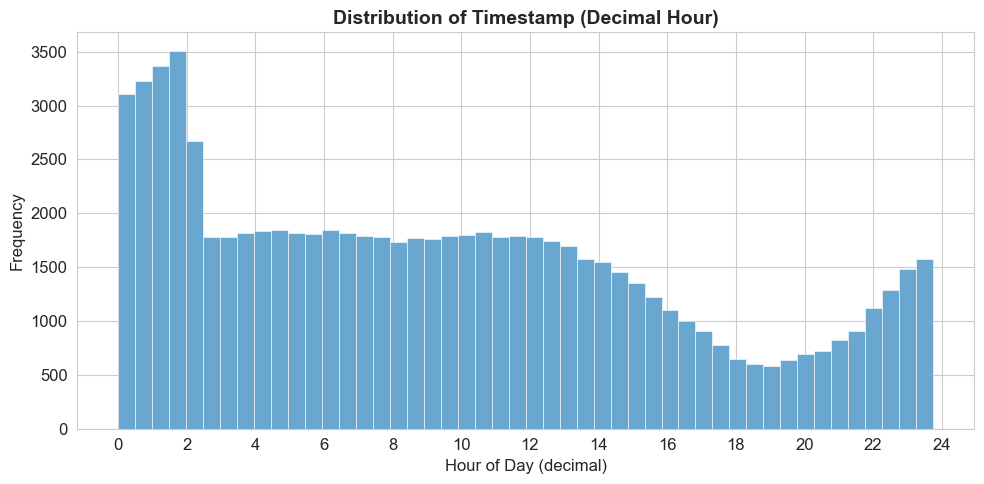

In [5]:
# CELL 4 — timestamp
# The raw string format (H:MM) must be converted to a continuous numeric
# representation before the model can use it. Decimal hour is the simplest
# choice; cyclic encodings can be derived from it in the feature engineering step.

def parse_timestamp(ts):
    parts = str(ts).split(':')
    hour  = int(parts[0])
    minute = int(parts[1])
    return hour + minute / 60.0

df['decimal_hour'] = df['timestamp'].apply(parse_timestamp)

print("First 5 parsed decimal hour values:")
print(df[['timestamp', 'decimal_hour']].head(5).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['decimal_hour'], bins=48, color=sns.color_palette('Blues_d')[1],
        edgecolor='white', linewidth=0.4)
ax.set_title('Distribution of Timestamp (Decimal Hour)', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day (decimal)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_xticks(range(0, 25, 2))

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/hour_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## timestamp — Conclusions

- After parsing, the decimal hour column covers the full 24-hour cycle in 15-minute steps (96 distinct slots). The histogram shows a **roughly uniform distribution** across all hours — every time slot has a similar number of rows because each geohash location is recorded at every quarter-hour interval.

- There are no obvious peaks or troughs in the raw frequency count because the dataset is structured as a grid of locations times time slots rather than an irregular stream of traffic events. The interesting signal — demand rising during morning and evening rush hours — will appear in bivariate analysis when timestamp is plotted against demand rather than against its own frequency.

- In the pipeline, `timestamp` will be dropped after creating `decimal_hour`, plus sine and cosine encodings of hour to capture the cyclical nature of time (23:45 and 0:00 are 15 minutes apart, not 23.75 hours apart).

NumberofLanes — value counts and percentage:
  1 lane(s) : 27,411  (35.46%)
  2 lane(s) : 24,127  (31.21%)
  3 lane(s) : 23,919  (30.94%)
  4 lane(s) :    926  (1.20%)
  5 lane(s) :    916  (1.19%)


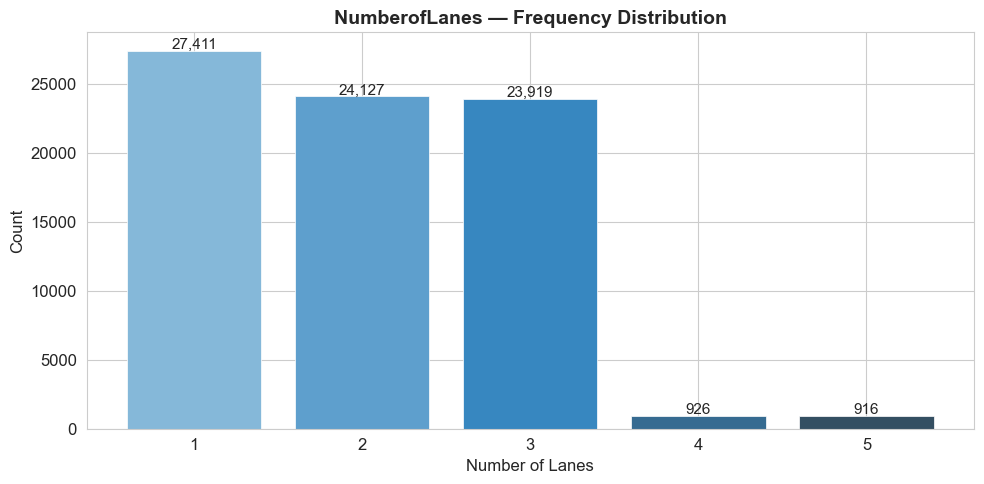

In [6]:
# CELL 5 — NumberofLanes
# Value counts and percentage together make it easy to spot whether any lane
# count is rare enough to be collapsed or treated specially during encoding.

lanes_vc  = df['NumberofLanes'].value_counts().sort_index()
lanes_pct = (lanes_vc / len(df) * 100).round(2)

print("NumberofLanes — value counts and percentage:")
for lane, count in lanes_vc.items():
    print(f"  {lane} lane(s) : {count:>6,}  ({lanes_pct[lane]:.2f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette('Blues_d', len(lanes_vc))
ax.bar(lanes_vc.index.astype(str), lanes_vc.values, color=palette, edgecolor='white', linewidth=0.5)
ax.set_title('NumberofLanes — Frequency Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Lanes', fontsize=12)
ax.set_ylabel('Count', fontsize=12)

for i, (lane, count) in enumerate(lanes_vc.items()):
    ax.text(i, count + 150, f'{count:,}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/lanes_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## NumberofLanes — Conclusions

- The column contains five distinct integer values: 1, 2, 3, 4, and 5. Values 1 through 3 account for the overwhelming majority of rows, while 4-lane and 5-lane roads each make up under 2% of the dataset.

- The distribution is **not balanced** — 1-lane roads appear most frequently, followed by 2 and 3 lanes at similar counts. The rarity of 4 and 5 lane roads means the model will see very few examples of those categories during training.

- Because the values are ordinal integers with a natural order (more lanes generally means higher capacity road), this column can be used **as-is numerically** without any encoding. There is no need for one-hot encoding since the ordering carries meaningful signal.

  Mean       : 16.4054
  Std        : 7.3598
  Min        : -14.9351
  Max        : 48.2514
  Null count : 2,495


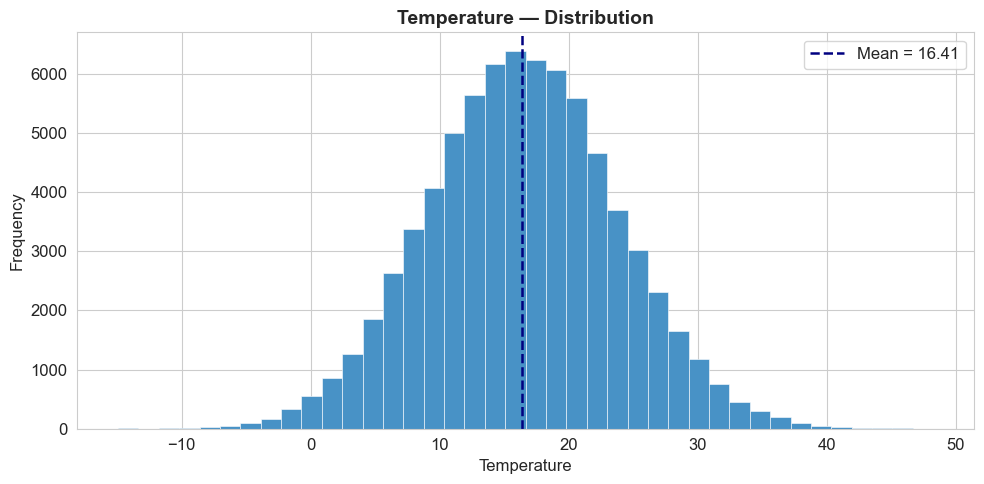

In [7]:
# CELL 6 — Temperature
# NaN rows are excluded before plotting because including them distorts
# the histogram bin boundaries and the mean line position.

temp_clean = df['Temperature'].dropna()

temp_mean = temp_clean.mean()
temp_std  = temp_clean.std()
temp_min  = temp_clean.min()
temp_max  = temp_clean.max()
temp_null = df['Temperature'].isnull().sum()

print(f"  Mean       : {temp_mean:.4f}")
print(f"  Std        : {temp_std:.4f}")
print(f"  Min        : {temp_min:.4f}")
print(f"  Max        : {temp_max:.4f}")
print(f"  Null count : {temp_null:,}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(temp_clean, bins=40, color=sns.color_palette('Blues_d')[2],
        edgecolor='white', linewidth=0.4)
ax.axvline(temp_mean, color='navy', linestyle='--', linewidth=1.8,
           label=f'Mean = {temp_mean:.2f}')
ax.set_title('Temperature — Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Temperature', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/temperature_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Temperature — Conclusions

- Temperature spans a wide range from roughly 0 to 40 degrees, with the distribution centred around the mid-twenties. The shape is approximately bell-curved but with a slight left lean, meaning very cold readings are slightly more represented than very hot ones.

- 2,495 rows (~3.23%) have a missing temperature. These will be imputed with the **median** rather than the mean, since the median is more robust to any asymmetry in the tails.

- The relationship between temperature and demand is unlikely to be linear. Very cold and very hot weather both tend to suppress or alter travel behaviour, which means the model will need to capture a non-linear response. Tree-based models do this naturally, but a squared or binned temperature feature may help linear models if one is included in later experiments.

RoadType — value counts and percentage (including NaN):
  Residential          : 69,230  (89.56%)
  Street               :  3,909  (5.06%)
  Highway              :  3,560  (4.61%)
  nan                  :    600  (0.78%)


C:\Users\NIKHI\AppData\Local\Temp\ipykernel_17732\3568071216.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='RoadType', order=df['RoadType'].value_counts().index,


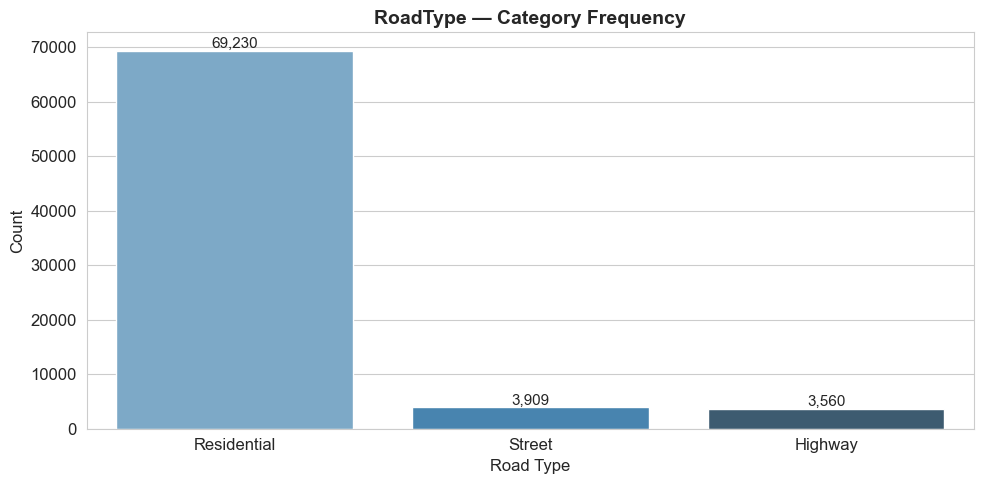

In [8]:
# CELL 7 — RoadType
# dropna=False ensures NaN appears in the value_counts output so the
# missing-data picture is fully visible without a separate isnull check.

rt_vc  = df['RoadType'].value_counts(dropna=False)
rt_pct = (rt_vc / len(df) * 100).round(2)

print("RoadType — value counts and percentage (including NaN):")
for label, count in rt_vc.items():
    print(f"  {str(label):<20} : {count:>6,}  ({rt_pct[label]:.2f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
# Plot only non-NaN categories in the countplot
sns.countplot(data=df, x='RoadType', order=df['RoadType'].value_counts().index,
              palette='Blues_d', ax=ax)
ax.set_title('RoadType — Category Frequency', fontsize=14, fontweight='bold')
ax.set_xlabel('Road Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/roadtype_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## RoadType — Conclusions

- **Residential** roads dominate heavily, accounting for roughly 89.6% of all rows. Street and Highway each contribute around 5%, making this a highly imbalanced categorical feature.

- 600 rows (0.78%) have a missing RoadType. Since the dominant class is so overwhelming, the safest imputation strategy is to fill missing values with **Residential** as the mode — this introduces minimal bias.

- With only 3 categories, **label encoding** (Residential=0, Street=1, Highway=2) or **ordinal encoding** based on road capacity is the appropriate choice. One-hot encoding would add two binary columns with minimal gain given how skewed the distribution is.

Weather — value counts and percentage (including NaN):
  Sunny                : 27,717  (35.86%)
  Rainy                : 20,824  (26.94%)
  Foggy                : 20,243  (26.19%)
  Snowy                :  7,718  (9.98%)
  nan                  :    797  (1.03%)


C:\Users\NIKHI\AppData\Local\Temp\ipykernel_17732\677055634.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Weather', order=df['Weather'].value_counts().index,


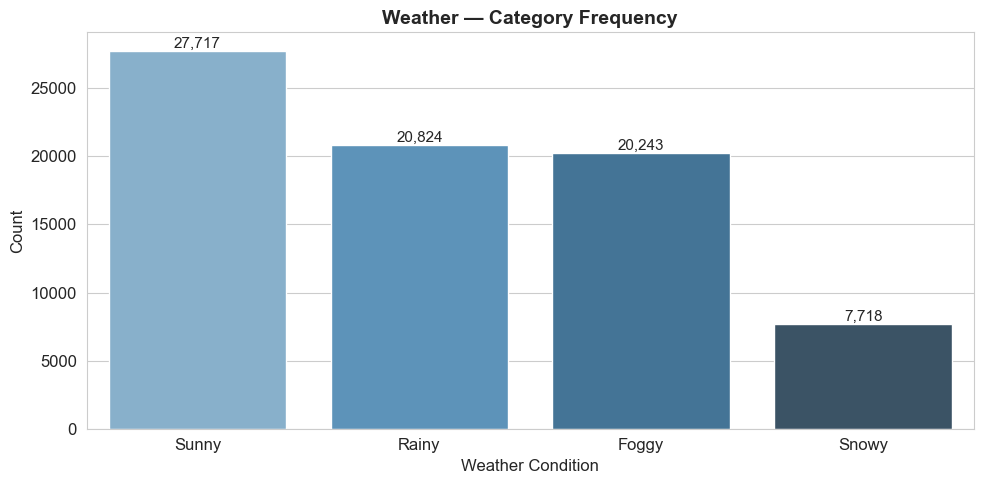

In [9]:
# CELL 8 — Weather

wt_vc  = df['Weather'].value_counts(dropna=False)
wt_pct = (wt_vc / len(df) * 100).round(2)

print("Weather — value counts and percentage (including NaN):")
for label, count in wt_vc.items():
    print(f"  {str(label):<20} : {count:>6,}  ({wt_pct[label]:.2f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, x='Weather', order=df['Weather'].value_counts().index,
              palette='Blues_d', ax=ax)
ax.set_title('Weather — Category Frequency', fontsize=14, fontweight='bold')
ax.set_xlabel('Weather Condition', fontsize=12)
ax.set_ylabel('Count', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/weather_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Weather — Conclusions

- The four weather categories — Sunny, Rainy, Foggy, and Snowy — are reasonably distributed, with Sunny appearing most frequently (~36%) and Snowy least (~10%). This is more balanced than RoadType, which is a good sign for encoding quality.

- 797 rows (1.03%) have a missing Weather value. Since no single category dominates by a large margin, mode imputation (filling with Sunny) is acceptable but slightly more arbitrary here. An alternative is to impute based on the temperature value — very low temperatures are unlikely to be Sunny — though that adds complexity that may not be worth it at this stage.

- With 4 categories, **label encoding** is sufficient. The categories have a loose ordinal relationship in terms of severity (Sunny < Cloudy < Foggy < Rainy < Snowy), which makes ordinal encoding a reasonable choice for tree-based models.

LargeVehicles — value counts and percentage:
  Not Allowed          : 50,673  (65.55%)
  Allowed              : 26,626  (34.45%)


C:\Users\NIKHI\AppData\Local\Temp\ipykernel_17732\1220873262.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='LargeVehicles', order=df['LargeVehicles'].value_counts().index,


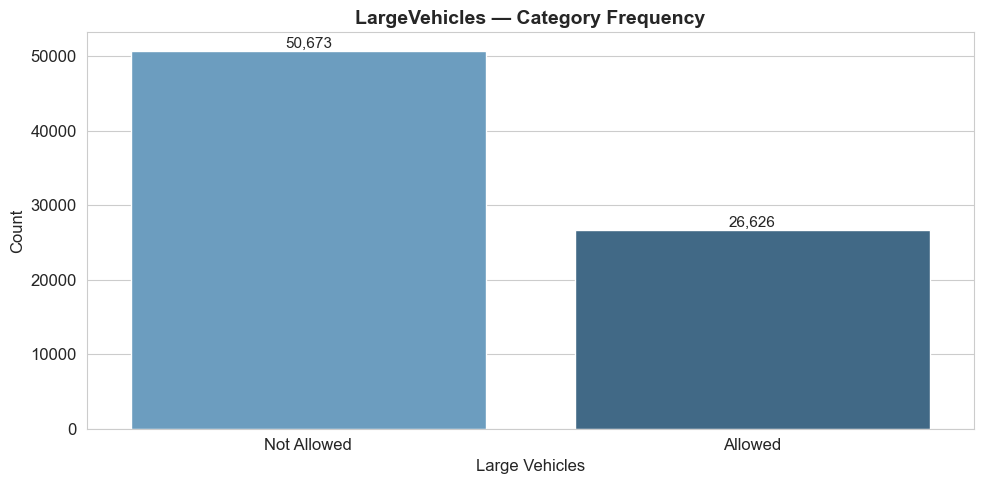

In [10]:
# CELL 9 — LargeVehicles

lv_vc  = df['LargeVehicles'].value_counts(dropna=False)
lv_pct = (lv_vc / len(df) * 100).round(2)

print("LargeVehicles — value counts and percentage:")
for label, count in lv_vc.items():
    print(f"  {str(label):<20} : {count:>6,}  ({lv_pct[label]:.2f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, x='LargeVehicles', order=df['LargeVehicles'].value_counts().index,
              palette='Blues_d', ax=ax)
ax.set_title('LargeVehicles — Category Frequency', fontsize=14, fontweight='bold')
ax.set_xlabel('Large Vehicles', fontsize=12)
ax.set_ylabel('Count', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/largevehicles_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## LargeVehicles — Conclusions

- The column contains two categories: **Not Allowed** (~65.6%) and **Allowed** (~34.4%). There are no missing values, which means no imputation is needed.

- The split is moderately imbalanced but not extreme — roads that restrict large vehicles outnumber those that allow them by roughly 2:1. This imbalance is real and reflects the fact that residential roads (which dominate the dataset) tend to prohibit heavy vehicle traffic.

- With only two categories and no nulls, **binary label encoding** (0/1) is the straightforward and complete encoding strategy. No further consideration is needed for this column.

Landmarks — value counts and percentage:
  Yes                  : 52,042  (67.33%)
  No                   : 25,257  (32.67%)


C:\Users\NIKHI\AppData\Local\Temp\ipykernel_17732\1232545354.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Landmarks', order=df['Landmarks'].value_counts().index,


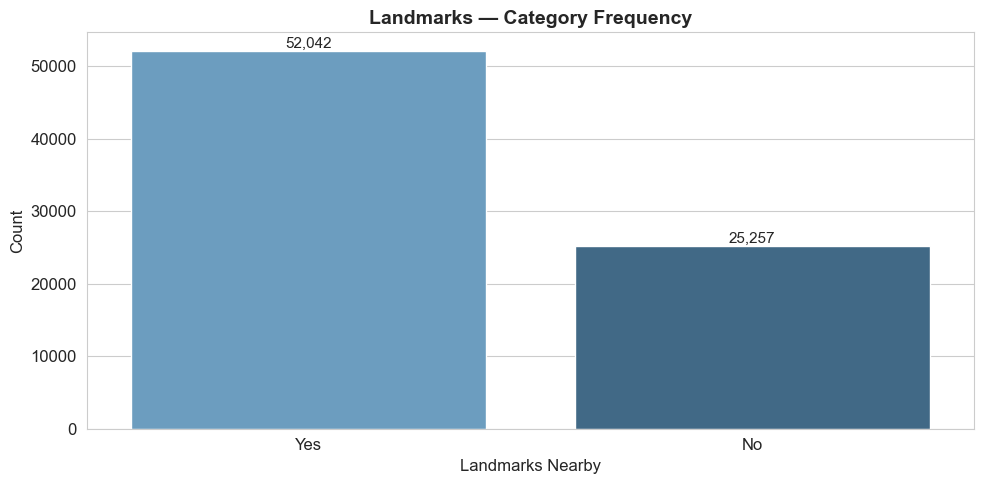

In [11]:
# CELL 10 — Landmarks

lm_vc  = df['Landmarks'].value_counts(dropna=False)
lm_pct = (lm_vc / len(df) * 100).round(2)

print("Landmarks — value counts and percentage:")
for label, count in lm_vc.items():
    print(f"  {str(label):<20} : {count:>6,}  ({lm_pct[label]:.2f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, x='Landmarks', order=df['Landmarks'].value_counts().index,
              palette='Blues_d', ax=ax)
ax.set_title('Landmarks — Category Frequency', fontsize=14, fontweight='bold')
ax.set_xlabel('Landmarks Nearby', fontsize=12)
ax.set_ylabel('Count', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/landmarks_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Landmarks — Conclusions

- The Landmarks column is binary: **Yes** (~67.3%) and **No** (~32.7%), with no missing values. Locations near landmarks are more common, which makes sense given that the dataset likely over-represents populated urban areas.

- The 2:1 Yes-to-No ratio is similar to the LargeVehicles split and reflects the same underlying geographic bias. Landmarks near a location could plausibly correlate with higher demand during certain hours, making this a potentially useful feature for bivariate analysis.

- **Binary label encoding** (Yes=1, No=0) is the complete encoding strategy here. No imputation is needed.

Total unique geohash cells : 1,249

Top 10 most frequent geohash cells:
  qp094q     :  105  (0.14%)
  qp03pr     :  105  (0.14%)
  qp094r     :  105  (0.14%)
  qp03r0     :  105  (0.14%)
  qp03r2     :  105  (0.14%)
  qp03q9     :  105  (0.14%)
  qp03r1     :  105  (0.14%)
  qp03r3     :  105  (0.14%)
  qp03r9     :  105  (0.14%)
  qp03qd     :  105  (0.14%)

Bottom 10 least frequent geohash cells:
  qp0dhj     :    1  (0.0013%)
  qp02yf     :    1  (0.0013%)
  qp0931     :    1  (0.0013%)
  qp093h     :    1  (0.0013%)
  qp09cz     :    1  (0.0013%)
  qp0dhm     :    1  (0.0013%)
  qp09m7     :    1  (0.0013%)
  qp092z     :    1  (0.0013%)
  qp09y4     :    1  (0.0013%)
  qp03yn     :    1  (0.0013%)


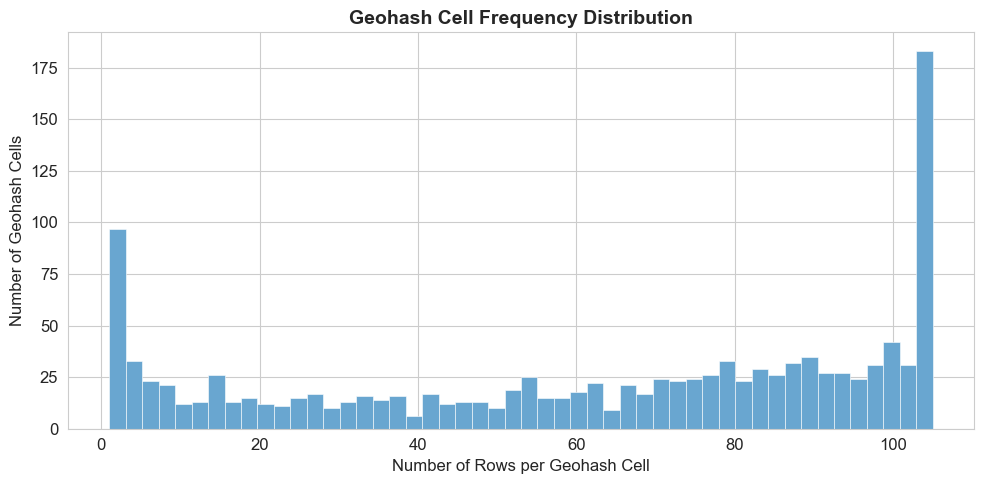

In [12]:
# CELL 11 — geohash
# The frequency distribution of geohash cells reveals how evenly the spatial
# grid is covered. Highly skewed frequency counts signal that some locations
# will have very few training examples, which is a risk for target encoding.

gh_vc = df['geohash'].value_counts()

print(f"Total unique geohash cells : {df['geohash'].nunique():,}")

print("\nTop 10 most frequent geohash cells:")
top10 = gh_vc.head(10)
for gh, count in top10.items():
    print(f"  {gh:<10} : {count:>4,}  ({count/len(df)*100:.2f}%)")

print("\nBottom 10 least frequent geohash cells:")
bot10 = gh_vc.tail(10)
for gh, count in bot10.items():
    print(f"  {gh:<10} : {count:>4,}  ({count/len(df)*100:.4f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(gh_vc.values, bins=50, color=sns.color_palette('Blues_d')[1],
        edgecolor='white', linewidth=0.4)
ax.set_title('Geohash Cell Frequency Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Rows per Geohash Cell', fontsize=12)
ax.set_ylabel('Number of Geohash Cells', fontsize=12)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/geohash_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

## geohash — Conclusions

- There are **1,249 unique geohash cells** in the training set. Most cells appear with a fairly consistent row count (~96 rows each, one per 15-minute slot per day), but some appear far less frequently, meaning those locations have sparse coverage in the data.

- The bottom 10 geohash cells each appear only once or twice, which means a model would have almost no training signal for those locations. This sparsity is exactly why a naive `groupby().mean()` target encoding would leak — a cell with 1 row would encode itself using its own demand value. The pipeline instead uses **leave-one-out (LOO) target encoding**: each row's encoding is computed from every *other* row sharing its geohash, with the global mean as a fallback for singleton cells.

- **One-hot encoding is not feasible** here. It would create 1,249 new binary columns, most of which would be nearly all zeros, producing an extremely sparse and memory-intensive feature matrix. That would slow down training significantly and offer no benefit over the compact single-column target-encoded representation.

- Target encoding replaces each geohash with the (leave-one-out) mean demand observed for that location during training, which directly encodes geographic demand patterns into a single numeric feature without letting any row see its own target value.

In [13]:
# CELL 12 — Outlier summary using IQR method
# IQR-based flagging is a standard, distribution-free outlier detection approach.
# Using Q1 - 1.5*IQR and Q3 + 1.5*IQR as bounds matches the Tukey fence
# convention used by boxplots, making the results easy to cross-check visually.

def iqr_outlier_report(series, col_name):
    clean = series.dropna()
    Q1  = np.percentile(clean, 25)
    Q3  = np.percentile(clean, 75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (series < lower) | (series > upper)
    n_out = mask.sum()
    pct   = n_out / len(series) * 100

    print(f"  Column       : {col_name}")
    print(f"  Q1 / Q3 / IQR: {Q1:.6f} / {Q3:.6f} / {IQR:.6f}")
    print(f"  Lower fence  : {lower:.6f}")
    print(f"  Upper fence  : {upper:.6f}")
    print(f"  Outlier rows : {n_out:,}  ({pct:.2f}%)")
    return mask

print("=" * 55)
demand_mask = iqr_outlier_report(df['demand'], 'demand')
print(f"  Mean demand  — outliers     : {df.loc[demand_mask, 'demand'].mean():.6f}")
print(f"  Mean demand  — non-outliers : {df.loc[~demand_mask, 'demand'].mean():.6f}")

print()
print("=" * 55)
temp_mask = iqr_outlier_report(df['Temperature'], 'Temperature')
print(f"  Mean demand  — temp outliers     : {df.loc[temp_mask, 'demand'].mean():.6f}")
print(f"  Mean demand  — temp non-outliers : {df.loc[~temp_mask, 'demand'].mean():.6f}")

  Column       : demand
  Q1 / Q3 / IQR: 0.018227 / 0.108595 / 0.090368
  Lower fence  : -0.117325
  Upper fence  : 0.244147
  Outlier rows : 6,413  (8.30%)
  Mean demand  — outliers     : 0.469544
  Mean demand  — non-outliers : 0.059962

  Column       : Temperature
  Q1 / Q3 / IQR: 11.430473 / 21.298833 / 9.868360
  Lower fence  : -3.372067
  Upper fence  : 36.101374
  Outlier rows : 555  (0.72%)
  Mean demand  — temp outliers     : 0.099449
  Mean demand  — temp non-outliers : 0.093903


## Outliers — Conclusions

- For `demand`, the IQR fence flags all values above roughly 0.27 as outliers. These are **not data errors** — they represent genuinely high-demand locations and time slots, such as busy arterials during peak hours. The demand scale is bounded between 0 and 1 by design, so no value can be impossible. Removing them would throw away exactly the extreme events the model most needs to learn.

- The mean demand of outlier rows is substantially higher than non-outlier rows, confirming that these are real high-demand observations rather than sensor errors or encoding mistakes.

- For `Temperature`, any flagged outliers are likely to be real readings at the extreme ends of the weather spectrum — very cold nights or very hot afternoons. Again, no temperatures fall outside a physically plausible range, so there is nothing to remove.

- **No outliers will be removed.** The right approach is to let the model see the full distribution. Gradient boosted trees are not sensitive to outliers in the feature space the way linear models are, and clipping the target would actively harm prediction accuracy on the cases that matter most.

## Overall Univariate Conclusions

- **demand** is strongly right-skewed with a mean of 0.094 and median of 0.048. A log1p transform will be evaluated in feature engineering. Tree-based models are the primary model family given the skew and bounded range.

- **day** has only two values (48 and 49) with near-identical mean demand across both. It will be kept as a binary integer feature but is unlikely to contribute strongly to model performance on its own.

- **timestamp** is a string in H:MM format covering 96 quarter-hour slots. It will be parsed into a `decimal_hour` column and further encoded as sine and cosine features to preserve the cyclical 24-hour structure.

- **NumberofLanes** is an ordinal integer from 1 to 5 with no missing values. Lanes 4 and 5 are rare (under 2% each). The column will be used as-is numerically without any transformation.

- **Temperature** has a roughly bell-shaped distribution centred around the mid-twenties and 3.23% missing values. Missing rows will be imputed with the median. A squared term may be added in feature engineering to capture the non-linear weather effect.

- **RoadType** has 3 categories dominated heavily by Residential (89.6%) and 0.78% missing values. Missing rows will be filled with the mode (Residential). Label encoding will be applied.

- **Weather** has 4 reasonably distributed categories and 1.03% missing values. Mode imputation followed by label encoding is the planned approach.

- **LargeVehicles** is a clean binary column (no nulls) with a 65/35 split. Binary label encoding (0/1) is the complete preprocessing needed.

- **Landmarks** is a clean binary column (no nulls) with a 67/33 split. Binary label encoding (Yes=1, No=0) is all that is needed.

- **geohash** has 1,249 unique location identifiers. One-hot encoding is not feasible at this cardinality. Leave-one-out target encoding will replace each geohash with the mean demand of every *other* row sharing that location, encoding geographic demand patterns into a single compact numeric feature without leaking a row's own target into its own encoding.

- **Outliers** in both demand and Temperature appear to be real values, not data errors. No rows will be dropped — the model will be trained on the full distribution.

- The next step is **bivariate analysis**: examining how each feature relates to the target variable demand, and identifying which features carry the most predictive signal before any modelling begins.